# Selected Geographic Metrics

This notebook contains the ordered analysis requested for the longitudinal study of Prix de Lausanne finalist origins.

In [10]:
from pathlib import Path
from html import escape

import numpy as np
import pandas as pd

try:
    from IPython.display import SVG, display
except ModuleNotFoundError:
    class SVG:
        def __init__(self, data):
            self.data = data

    def display(obj):
        print(obj)

In [11]:
INPUT_PATH = Path(r"C:\Users\lenovo\DH412\Other_Analysis.csv")
OUTPUT_DIR = Path(r"C:\Users\lenovo\DH412\results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(INPUT_PATH)
df["year"] = pd.to_numeric(df["year"], errors="coerce")
if "decade" in df.columns:
    df["decade"] = pd.to_numeric(df["decade"], errors="coerce")
else:
    df["decade"] = (df["year"] // 10) * 10

df["year"] = df["year"].astype("Int64")
df["decade"] = df["decade"].astype("Int64")
df["country"] = df["countries"].astype("string").str.strip().replace({"": pd.NA})
df["continent_clean"] = df["continent"].astype("string").str.strip().replace({"": pd.NA})

display(df[["year", "decade", "country", "continent_clean"]].head())

,year,decade,country,continent_clean
0,1973,1970,France,Europe
1,1973,1970,Belgium,Europe
2,1973,1970,Belgium,Europe
3,1973,1970,Canada,North America
4,1973,1970,France,Europe


In [12]:
def entropy(proportions: pd.Series) -> float:
    p = proportions.dropna()
    p = p[p > 0]
    if p.empty:
        return float("nan")
    return float(-(p * np.log(p)).sum())


def distribution_by_period(data: pd.DataFrame, period_col: str, label_col: str, label_name: str) -> pd.DataFrame:
    valid = data.dropna(subset=[period_col, label_col]).copy()
    counts = (
        valid.groupby([period_col, label_col], dropna=False)
        .size()
        .rename("count")
        .reset_index()
    )
    totals = counts.groupby(period_col)["count"].transform("sum")
    counts["proportion"] = counts["count"] / totals
    counts["rank"] = counts.groupby(period_col)["proportion"].rank(method="first", ascending=False)
    counts = counts.sort_values([period_col, "rank", label_col]).reset_index(drop=True)
    return counts.rename(columns={period_col: "period", label_col: label_name})


def concentration_for_many(country_dist: pd.DataFrame, top_m_values: list[int]) -> pd.DataFrame:
    tables = []
    for m in top_m_values:
        table = (
            country_dist.query("rank <= @m")
            .groupby("period")["proportion"]
            .sum()
            .rename(f"top_{m}_concentration")
            .reset_index()
        )
        tables.append(table)

    result = tables[0]
    for table in tables[1:]:
        result = result.merge(table, on="period", how="outer")
    return result.sort_values("period").reset_index(drop=True)


def print_values(data: pd.DataFrame, title: str, period_label: str) -> None:
    print(title)
    display(data.rename(columns={"period": period_label}))


def display_line_chart(data: pd.DataFrame, y_cols: list[str], title: str, y_label: str, x_label: str, x_suffix: str = "") -> None:
    chart = data[["period", *y_cols]].dropna().copy()
    chart["period"] = chart["period"].astype(int)
    width, height = 780, 380
    margin = {"left": 72, "right": 190, "top": 54, "bottom": 58}
    plot_w = width - margin["left"] - margin["right"]
    plot_h = height - margin["top"] - margin["bottom"]
    x_values = chart["period"].to_numpy(dtype=float)
    y_values = chart[y_cols].to_numpy(dtype=float).ravel()
    y_min = min(0.0, float(np.nanmin(y_values)))
    y_max = float(np.nanmax(y_values))
    if y_min == y_max:
        y_max = y_min + 1.0
    x_min, x_max = float(np.nanmin(x_values)), float(np.nanmax(x_values))
    if x_min == x_max:
        x_max = x_min + 1.0

    def sx(x):
        return margin["left"] + (x - x_min) / (x_max - x_min) * plot_w

    def sy(y):
        return margin["top"] + (y_max - y) / (y_max - y_min) * plot_h

    colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e"]
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        f'<text x="{width / 2}" y="26" text-anchor="middle" font-size="18" font-family="Arial" font-weight="700">{escape(title)}</text>',
    ]
    for i in range(5):
        y = y_min + (y_max - y_min) * i / 4
        py = sy(y)
        parts.append(f'<line x1="{margin["left"]}" y1="{py:.1f}" x2="{width - margin["right"]}" y2="{py:.1f}" stroke="#e6e6e6"/>')
        parts.append(f'<text x="{margin["left"] - 10}" y="{py + 4:.1f}" text-anchor="end" font-size="12" font-family="Arial" fill="#444">{y:.2f}</text>')

    parts.append(f'<line x1="{margin["left"]}" y1="{height - margin["bottom"]}" x2="{width - margin["right"]}" y2="{height - margin["bottom"]}" stroke="#333"/>')
    parts.append(f'<line x1="{margin["left"]}" y1="{margin["top"]}" x2="{margin["left"]}" y2="{height - margin["bottom"]}" stroke="#333"/>')
    tick_every = max(1, int(np.ceil(len(chart) / 12)))
    last_tick = len(chart) - 1
    for tick_idx, x_value in enumerate(chart["period"]):
        if tick_idx % tick_every != 0 and tick_idx != last_tick:
            continue
        px = sx(float(x_value))
        parts.append(f'<text x="{px:.1f}" y="{height - margin["bottom"] + 24}" text-anchor="middle" font-size="12" font-family="Arial" fill="#444">{int(x_value)}{escape(x_suffix)}</text>')

    parts.append(f'<text x="{margin["left"] + plot_w / 2}" y="{height - 14}" text-anchor="middle" font-size="13" font-family="Arial">{escape(x_label)}</text>')
    parts.append(f'<text x="18" y="{margin["top"] + plot_h / 2}" transform="rotate(-90 18 {margin["top"] + plot_h / 2})" text-anchor="middle" font-size="13" font-family="Arial">{escape(y_label)}</text>')

    for idx, col in enumerate(y_cols):
        color = colors[idx % len(colors)]
        points = " ".join(f'{sx(float(row["period"])):.1f},{sy(float(row[col])):.1f}' for _, row in chart.iterrows())
        parts.append(f'<polyline fill="none" stroke="{color}" stroke-width="2.5" points="{points}"/>')
        for _, row in chart.iterrows():
            parts.append(f'<circle cx="{sx(float(row["period"])):.1f}" cy="{sy(float(row[col])):.1f}" r="4" fill="{color}"/>')
        legend_y = margin["top"] + 22 * idx
        parts.append(f'<line x1="{width - margin["right"] + 20}" y1="{legend_y}" x2="{width - margin["right"] + 44}" y2="{legend_y}" stroke="{color}" stroke-width="2.5"/>')
        parts.append(f'<text x="{width - margin["right"] + 52}" y="{legend_y + 4}" font-size="12" font-family="Arial" fill="#333">{escape(col)}</text>')

    parts.append("</svg>")
    display(SVG("".join(parts)))


def display_stacked_area_chart(
    data: pd.DataFrame,
    x_col: str,
    y_cols: list[str],
    title: str,
    y_label: str = "Proportion",
    x_label: str = "Decade",
    x_suffix: str = "s",
) -> None:
    """Display a dependency-free SVG stacked area chart."""
    chart = data[[x_col, *y_cols]].fillna(0).copy()
    chart[x_col] = chart[x_col].astype(int)
    width, height = 840, 430
    margin = {"left": 72, "right": 190, "top": 54, "bottom": 58}
    plot_w = width - margin["left"] - margin["right"]
    plot_h = height - margin["top"] - margin["bottom"]

    x_values = chart[x_col].to_numpy(dtype=float)
    x_min, x_max = float(np.nanmin(x_values)), float(np.nanmax(x_values))
    if x_min == x_max:
        x_max = x_min + 1.0

    def sx(x):
        return margin["left"] + (x - x_min) / (x_max - x_min) * plot_w

    def sy(y):
        return margin["top"] + (1.0 - y) * plot_h

    colors = [
        "#4e79a7", "#f28e2b", "#e15759", "#76b7b2",
        "#59a14f", "#edc948", "#b07aa1", "#ff9da7",
        "#9c755f", "#bab0ab",
    ]
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        f'<text x="{width / 2}" y="26" text-anchor="middle" font-size="18" font-family="Arial" font-weight="700">{escape(title)}</text>',
    ]

    for i in range(5):
        y = i / 4
        py = sy(y)
        parts.append(f'<line x1="{margin["left"]}" y1="{py:.1f}" x2="{width - margin["right"]}" y2="{py:.1f}" stroke="#e6e6e6"/>')
        parts.append(f'<text x="{margin["left"] - 10}" y="{py + 4:.1f}" text-anchor="end" font-size="12" font-family="Arial" fill="#444">{y:.2f}</text>')

    parts.append(f'<line x1="{margin["left"]}" y1="{height - margin["bottom"]}" x2="{width - margin["right"]}" y2="{height - margin["bottom"]}" stroke="#333"/>')
    parts.append(f'<line x1="{margin["left"]}" y1="{margin["top"]}" x2="{margin["left"]}" y2="{height - margin["bottom"]}" stroke="#333"/>')

    for x_value in chart[x_col]:
        px = sx(float(x_value))
        parts.append(f'<text x="{px:.1f}" y="{height - margin["bottom"] + 24}" text-anchor="middle" font-size="12" font-family="Arial" fill="#444">{int(x_value)}{escape(x_suffix)}</text>')

    parts.append(f'<text x="{margin["left"] + plot_w / 2}" y="{height - 14}" text-anchor="middle" font-size="13" font-family="Arial">{escape(x_label)}</text>')
    parts.append(f'<text x="18" y="{margin["top"] + plot_h / 2}" transform="rotate(-90 18 {margin["top"] + plot_h / 2})" text-anchor="middle" font-size="13" font-family="Arial">{escape(y_label)}</text>')

    cumulative = np.zeros(len(chart))
    xs = chart[x_col].to_numpy(dtype=float)
    for idx, col in enumerate(y_cols):
        values = chart[col].to_numpy(dtype=float)
        lower = cumulative.copy()
        upper = cumulative + values
        cumulative = upper

        upper_points = [(sx(x), sy(y)) for x, y in zip(xs, upper)]
        lower_points = [(sx(x), sy(y)) for x, y in zip(xs[::-1], lower[::-1])]
        polygon = " ".join(f"{x:.1f},{y:.1f}" for x, y in upper_points + lower_points)
        color = colors[idx % len(colors)]
        parts.append(f'<polygon points="{polygon}" fill="{color}" opacity="0.82" stroke="white" stroke-width="1"/>')

        legend_y = margin["top"] + 22 * idx
        parts.append(f'<rect x="{width - margin["right"] + 20}" y="{legend_y - 9}" width="16" height="12" fill="{color}" opacity="0.82"/>')
        parts.append(f'<text x="{width - margin["right"] + 44}" y="{legend_y + 2}" font-size="12" font-family="Arial" fill="#333">{escape(col)}</text>')

    parts.append("</svg>")
    display(SVG("".join(parts)))


## Stacked area overview before Question 1

The following two stacked area charts summarize how finalist origins change over decades before the formal metric-based questions.

Proportion of finalists by country over decades: Top-6 countries + Others


country_group,period,Japan,France,USA,South Korea,China,Australia,Others
0,1970,0.025974,0.506494,0.025974,0.000000,0.000000,0.000000,0.441558
1,1980,0.186667,0.153333,0.053333,0.020000,0.040000,0.033333,0.513333
2,1990,0.177632,0.151316,0.065789,0.006579,0.013158,0.039474,0.546053
3,2000,0.210145,0.021739,0.065217,0.130435,0.108696,0.057971,0.405797
4,2010,0.190000,0.010000,0.140000,0.085000,0.125000,0.085000,0.365000
5,2020,0.145833,0.020833,0.145833,0.201389,0.125000,0.069444,0.291667


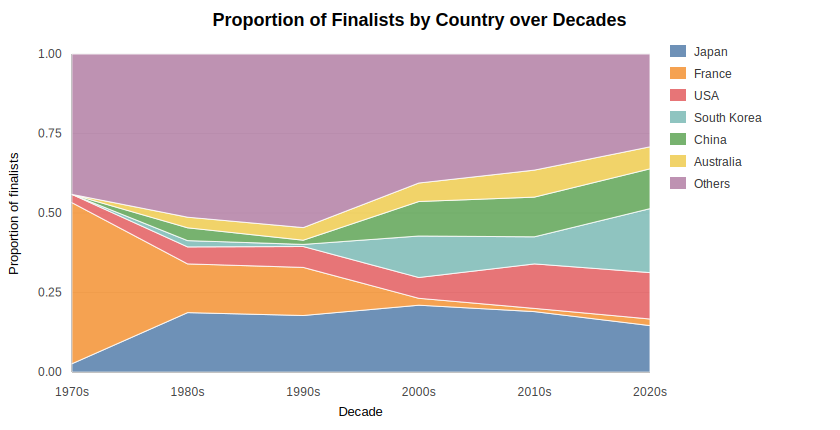

Proportion of finalists by continent over decades


continent_clean,period,Europe,Asia,North America,South America,Oceania,Africa
0,1970,0.935065,0.025974,0.038961,0.000000,0.000000,0.000000
1,1980,0.613333,0.246667,0.060000,0.013333,0.046667,0.020000
2,1990,0.631579,0.217105,0.092105,0.019737,0.039474,0.000000
3,2000,0.289855,0.485507,0.094203,0.065217,0.065217,0.000000
4,2010,0.205000,0.400000,0.170000,0.130000,0.090000,0.005000
5,2020,0.176056,0.478873,0.176056,0.091549,0.070423,0.007042


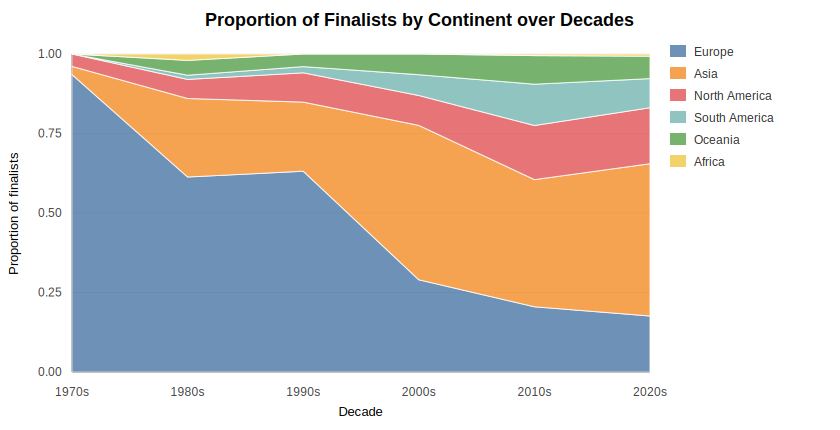

In [13]:
# Proportion of finalists by country over decades: Top-6 countries plus Others.
top_6_countries = (
    df["country"]
    .dropna()
    .value_counts()
    .head(6)
    .index
    .tolist()
)

country_area_df = df.dropna(subset=["decade", "country"]).copy()
country_area_df["country_group"] = np.where(country_area_df["country"].isin(top_6_countries), country_area_df["country"], "Others")
country_area = (
    country_area_df.groupby(["decade", "country_group"])
    .size()
    .rename("count")
    .reset_index()
)
country_area["proportion"] = country_area["count"] / country_area.groupby("decade")["count"].transform("sum")
country_area_wide = (
    country_area.pivot(index="decade", columns="country_group", values="proportion")
    .fillna(0)
    .reset_index()
    .rename(columns={"decade": "period"})
)
country_area_cols = [c for c in top_6_countries if c in country_area_wide.columns] + ["Others"]

print("Proportion of finalists by country over decades: Top-6 countries + Others")
display(country_area_wide[["period", *country_area_cols]])
display_stacked_area_chart(
    country_area_wide,
    "period",
    country_area_cols,
    "Proportion of Finalists by Country over Decades",
    "Proportion of finalists",
    "Decade",
    x_suffix="s",
)

# Proportion of finalists by continent over decades.
continent_area = (
    df.dropna(subset=["decade", "continent_clean"])
    .groupby(["decade", "continent_clean"])
    .size()
    .rename("count")
    .reset_index()
)
continent_area["proportion"] = continent_area["count"] / continent_area.groupby("decade")["count"].transform("sum")
continent_area_wide = (
    continent_area.pivot(index="decade", columns="continent_clean", values="proportion")
    .fillna(0)
    .reset_index()
    .rename(columns={"decade": "period"})
)
continent_area_cols = [c for c in ["Europe", "Asia", "North America", "South America", "Oceania", "Africa"] if c in continent_area_wide.columns]

print("Proportion of finalists by continent over decades")
display(continent_area_wide[["period", *continent_area_cols]])
display_stacked_area_chart(
    continent_area_wide,
    "period",
    continent_area_cols,
    "Proportion of Finalists by Continent over Decades",
    "Proportion of finalists",
    "Decade",
    x_suffix="s",
)

## Question 1: Country-level diversity by year

Country-level diversity is measured using Shannon entropy:

$$H_{country}^{(g)} = - \sum_i q_i^{(g)} \log q_i^{(g)}$$

Country-level entropy by year


,year,country_count,country_entropy
0,1973,3,0.974315
1,1974,2,0.673012
2,1975,2,0.682908
3,1976,7,1.661323
4,1977,6,1.540306
5,1978,5,1.080574
6,1979,7,1.714088
7,1980,8,1.951260
8,1981,9,1.965237
9,1982,8,1.840749


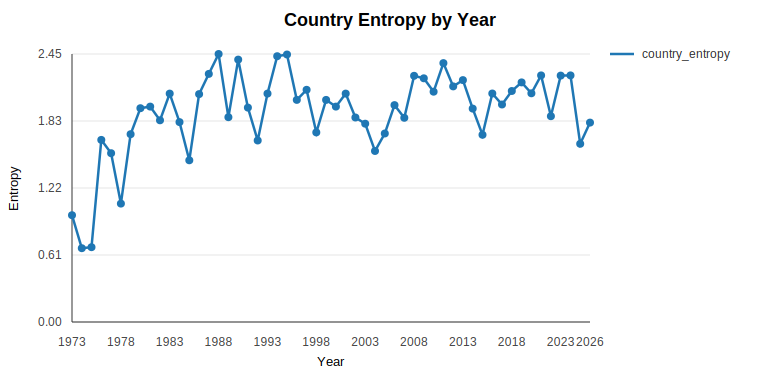

In [14]:
country_dist_year = distribution_by_period(df, "year", "country", "country")
country_entropy_year = (
    country_dist_year.groupby("period")
    .agg(country_count=("country", "nunique"), country_entropy=("proportion", entropy))
    .reset_index()
)

print_values(country_entropy_year, "Country-level entropy by year", "year")
display_line_chart(country_entropy_year, ["country_entropy"], "Country Entropy by Year", "Entropy", "Year")

## Question 2: HHI / Simpson country concentration by year

HHI, also known as Simpson concentration in diversity studies, is computed as:

$$HHI^{(g)} = \sum_i (q_i^{(g)})^2$$

Higher values indicate stronger concentration in a smaller number of countries.

HHI / Simpson country concentration by year


,year,hhi_simpson_concentration
0,1973,0.406250
1,1974,0.520000
2,1975,0.510204
3,1976,0.250000
4,1977,0.272727
5,1978,0.475556
6,1979,0.226667
7,1980,0.159763
8,1981,0.183673
9,1982,0.203125


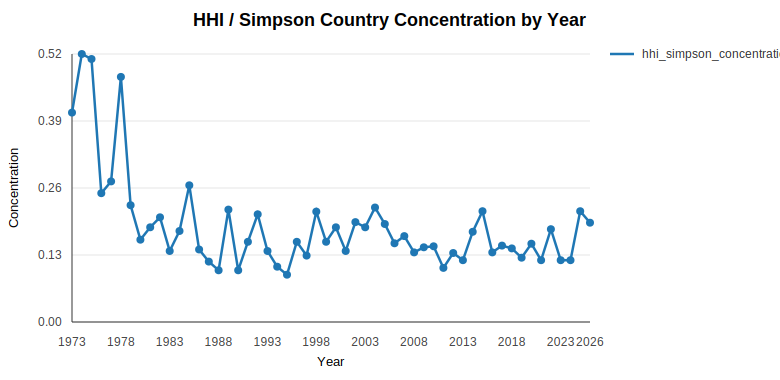

In [20]:
hhi_year = (
    country_dist_year.groupby("period")["proportion"]
    .apply(lambda s: float((s ** 2).sum()))
    .rename("hhi_simpson_concentration")
    .reset_index()
)

print_values(hhi_year, "HHI / Simpson country concentration by year", "year")
display_line_chart(hhi_year, ["hhi_simpson_concentration"], "HHI / Simpson Country Concentration by Year", "Concentration", "Year")

## Question 3: Continent-level diversity by year

Continent-level diversity is measured using Shannon entropy:

$$H_{continent}^{(g)} = - \sum_j r_j^{(g)} \log r_j^{(g)}$$

Continent-level entropy by year


,year,continent_count,continent_entropy
0,1973,2,0.376770
1,1974,1,-0.000000
2,1975,1,-0.000000
3,1976,1,-0.000000
4,1977,1,-0.000000
5,1978,2,0.244930
6,1979,3,0.627705
7,1980,3,0.790268
8,1981,4,0.895333
9,1982,4,0.950749


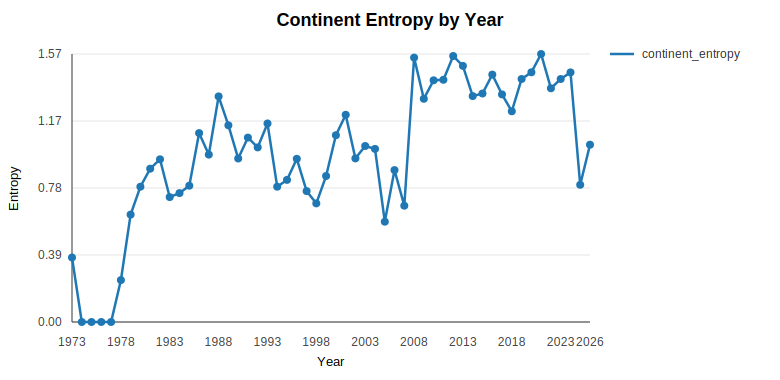

In [17]:
continent_dist_year = distribution_by_period(df, "year", "continent_clean", "continent")
continent_entropy_year = (
    continent_dist_year.groupby("period")
    .agg(continent_count=("continent", "nunique"), continent_entropy=("proportion", entropy))
    .reset_index()
)

print_values(continent_entropy_year, "Continent-level entropy by year", "year")
display_line_chart(continent_entropy_year, ["continent_entropy"], "Continent Entropy by Year", "Entropy", "Year")

## Question 4: HHI / Simpson continent concentration by year

HHI / Simpson concentration is also computed at the continent level:

$$HHI_{continent}^{(g)} = \sum_j (r_j^{(g)})^2$$

Higher values indicate stronger concentration in a smaller number of continents.

HHI / Simpson continent concentration by year


,year,hhi_simpson_continent_concentration
0,1973,0.781250
1,1974,1.000000
2,1975,1.000000
3,1976,1.000000
4,1977,1.000000
5,1978,0.875556
6,1979,0.662222
7,1980,0.538462
8,1981,0.540816
9,1982,0.507812


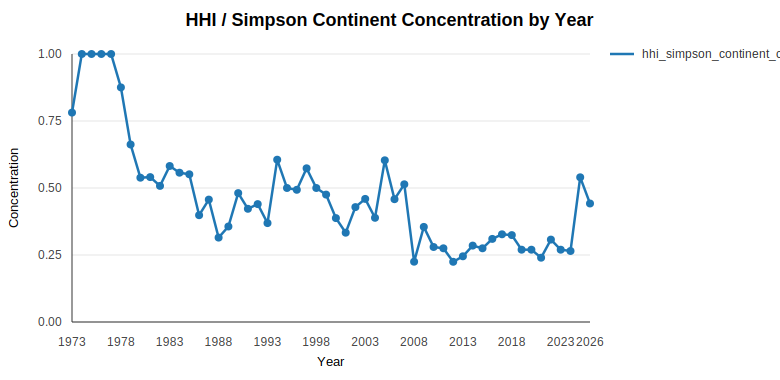

In [18]:
hhi_continent_year = (
    continent_dist_year.groupby("period")["proportion"]
    .apply(lambda s: float((s ** 2).sum()))
    .rename("hhi_simpson_continent_concentration")
    .reset_index()
)

print_values(hhi_continent_year, "HHI / Simpson continent concentration by year", "year")
display_line_chart(
    hhi_continent_year,
    ["hhi_simpson_continent_concentration"],
    "HHI / Simpson Continent Concentration by Year",
    "Concentration",
    "Year",
)

## Export selected outputs

In [21]:
country_area_wide[["period", *country_area_cols]].to_csv(OUTPUT_DIR / "stacked_area_country_top6_others_by_decade.csv", index=False)
continent_area_wide[["period", *continent_area_cols]].to_csv(OUTPUT_DIR / "stacked_area_continent_by_decade.csv", index=False)
country_entropy_year.to_csv(OUTPUT_DIR / "question_1_country_entropy_by_year.csv", index=False)
hhi_year.to_csv(OUTPUT_DIR / "question_2_hhi_simpson_country_concentration_by_year.csv", index=False)
continent_entropy_year.to_csv(OUTPUT_DIR / "question_3_continent_entropy_by_year.csv", index=False)
hhi_continent_year.to_csv(OUTPUT_DIR / "question_4_hhi_simpson_continent_concentration_by_year.csv", index=False)

print(f"Outputs written to: {OUTPUT_DIR}")

Outputs written to: C:\Users\lenovo\DH412\results
